In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from mlkem_gpu.cbd_gpu import poly_cbd_eta1, poly_cbd_eta2
from mlkem_gpu.cbd_gpu import poly_cbd_eta1_batched, poly_cbd_eta2_batched

from mlkem_gpu.device import DEVICE

In [2]:
device_name = str(DEVICE)

In [3]:
# CPU variant
buf_eta1 = torch.randint(
    0,
    256,
    size=(192,),
    dtype=torch.uint8,
    device=DEVICE,
)

buf_eta2 = torch.randint(
    0,
    256,
    size=(128,),
    dtype=torch.uint8,
    device=DEVICE,
)

p1 = poly_cbd_eta1(buf_eta1)
p2 = poly_cbd_eta2(buf_eta2)

print(p1)
print(p2)

print("ETA1 min/max:", min(p1.tolist()), max(p1.tolist()))
print("ETA2 min/max:", min(p2.tolist()), max(p2.tolist()))

print("ETA1 first 20:", p1.tolist()[:20])
print("ETA2 first 20:", p2.tolist()[:20])

Poly(coeffs_shape=(256,), device=mps:0)
Poly(coeffs_shape=(256,), device=mps:0)
ETA1 min/max: -3 3
ETA2 min/max: -2 2
ETA1 first 20: [0, 0, 0, 0, 0, 0, -1, -1, 1, 0, 0, -1, -1, 0, -2, -3, 0, 0, 0, 2]
ETA2 first 20: [-1, 0, 1, 1, -1, 0, 0, 1, 0, 0, 1, 0, 1, -1, 0, 0, 2, 1, 0, 0]


In [4]:
# GPU variant
batch_size = 1000

buf_eta1 = torch.randint(0, 256, (batch_size, 192), dtype=torch.uint8, device=DEVICE)
buf_eta2 = torch.randint(0, 256, (batch_size, 128), dtype=torch.uint8, device=DEVICE)

p_eta1 = poly_cbd_eta1_batched(buf_eta1)
p_eta2 = poly_cbd_eta2_batched(buf_eta2)

print(p_eta1.shape)
print(p_eta2.shape)

print("ETA1 min/max:", p_eta1.min().item(), p_eta1.max().item())
print("ETA2 min/max:", p_eta2.min().item(), p_eta2.max().item())

torch.Size([1000, 256])
torch.Size([1000, 256])
ETA1 min/max: -3 3
ETA2 min/max: -2 2


,eta,coefficient,count
0,eta1,-3,3978
1,eta1,-2,24166
2,eta1,-1,60347
3,eta1,0,79744
4,eta1,1,59658
5,eta1,2,24116
6,eta1,3,3991
7,eta2,-2,16034
8,eta2,-1,64007
9,eta2,0,95975


Saved: ../../reports/figures/cbd_noise_distribution_eta1_mps_batch_1000.png


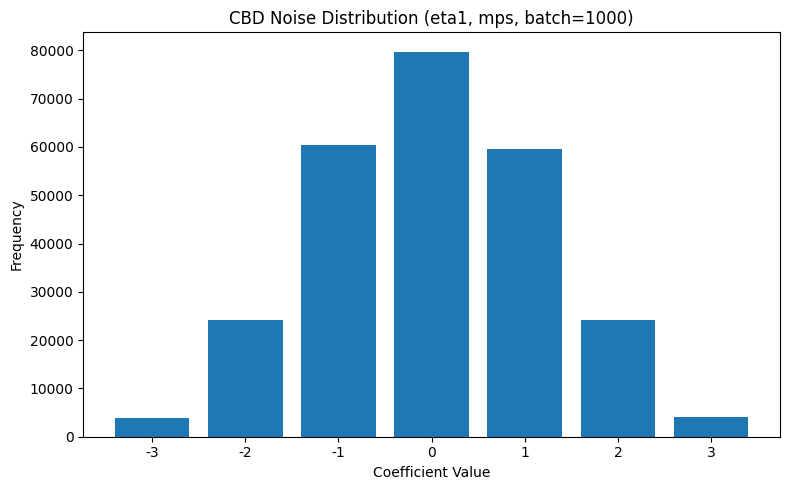

Saved: ../../reports/figures/cbd_noise_distribution_eta2_mps_batch_1000.png


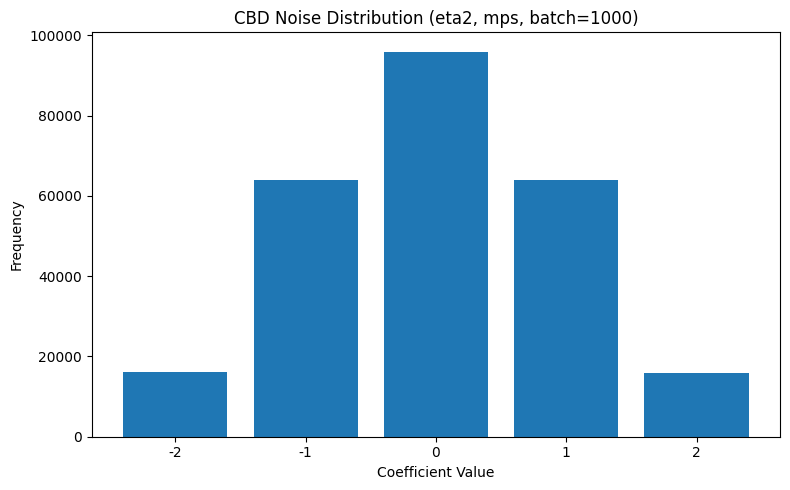

In [5]:
output_dir = Path("../../reports/figures")
output_dir.mkdir(parents=True, exist_ok=True)

eta1_values = p_eta1.detach().cpu().reshape(-1).numpy()
eta2_values = p_eta2.detach().cpu().reshape(-1).numpy()

df_eta1 = pd.DataFrame(
    {
        "coefficient": eta1_values,
        "eta": "eta1",
    }
)

df_eta2 = pd.DataFrame(
    {
        "coefficient": eta2_values,
        "eta": "eta2",
    }
)

df_noise = pd.concat(
    [df_eta1, df_eta2],
    ignore_index=True,
)

display(
    df_noise
    .groupby(["eta", "coefficient"])
    .size()
    .reset_index(name="count")
)

for eta_name, df_subset in df_noise.groupby("eta"):
    counts = (
        df_subset["coefficient"]
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(8, 5))

    plt.bar(
        counts.index.astype(str),
        counts.values,
    )

    plt.xlabel("Coefficient Value")
    plt.ylabel("Frequency")
    plt.title(
        f"CBD Noise Distribution ({eta_name}, {device_name}, batch={batch_size})"
    )

    plt.tight_layout()

    output_file = (
        output_dir /
        f"cbd_noise_distribution_{eta_name}_{device_name}_batch_{batch_size}.png"
    )

    plt.savefig(
        output_file,
        dpi=300,
        bbox_inches="tight",
    )

    print(f"Saved: {output_file}")

    plt.show()